# Backpropagation (PyTorch)

Backpropagation is the algorithm that trains neural networks: it applies the chain
rule to propagate the error from the output layer back through every earlier layer,
producing a gradient for every weight. An optimizer then nudges each weight a small
step against its gradient.

Here we build a tiny 2-layer MLP **from raw tensors** (no `nn.Module`) on the
`sklearn` digits dataset, so the forward pass, the loss, and the gradients computed
by `loss.backward()` (PyTorch's autograd engine) are all explicit and visible.

In [1]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(0)

In [2]:
digits = load_digits()
X, y = digits.data, digits.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
scaler = StandardScaler().fit(X_train)
X_train = torch.tensor(scaler.transform(X_train), dtype=torch.float32)
X_test = torch.tensor(scaler.transform(X_test), dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [3]:
# Manual parameters for a 64 -> 32 -> 10 MLP. requires_grad=True tells autograd
# to track every operation that uses these tensors, so it can backprop through them.
n_in, n_hidden, n_out = 64, 32, 10

W1 = (torch.randn(n_in, n_hidden) * 0.1).requires_grad_()  # scale first, then mark as leaf
b1 = torch.zeros(n_hidden, requires_grad=True)
W2 = (torch.randn(n_hidden, n_out) * 0.1).requires_grad_()
b2 = torch.zeros(n_out, requires_grad=True)
params = [W1, b1, W2, b2]


def forward(x):
    z1 = x @ W1 + b1          # linear layer 1
    a1 = torch.relu(z1)       # activation
    z2 = a1 @ W2 + b2         # linear layer 2 (logits)
    return z2


criterion = torch.nn.CrossEntropyLoss()
lr = 0.05

In [4]:
losses, grad_norms = [], []
for epoch in range(60):
    logits = forward(X_train)
    loss = criterion(logits, y_train)

    for p in params:
        if p.grad is not None:
            p.grad.zero_()
    loss.backward()  # <-- backpropagation happens here: autograd walks the graph
                      #     built during forward() and fills p.grad for every param

    with torch.no_grad():
        grad_norm = sum(p.grad.norm().item() for p in params)
        for p in params:
            p -= lr * p.grad  # manual gradient descent step, no optimizer object

    losses.append(loss.item())
    grad_norms.append(grad_norm)
    if (epoch + 1) % 10 == 0:
        print(f"epoch {epoch+1:3d}  loss {loss.item():.4f}  |grad| {grad_norm:.4f}")

epoch  10  loss 2.1090  |grad| 0.9043
epoch  20  loss 1.9322  |grad| 0.9241
epoch  30  loss 1.7486  |grad| 0.9609
epoch  40  loss 1.5570  |grad| 0.9901
epoch  50  loss 1.3648  |grad| 0.9854
epoch  60  loss 1.1854  |grad| 0.9427


Test accuracy: 0.783


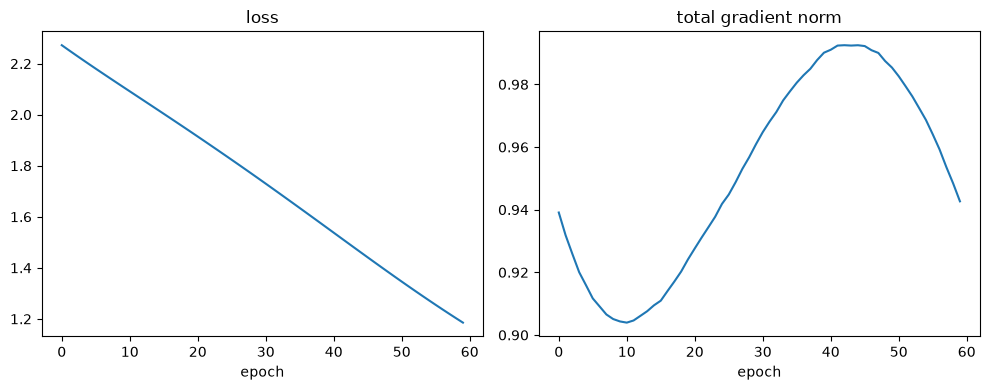

In [5]:
with torch.no_grad():
    preds = forward(X_test).argmax(dim=1)
    accuracy = (preds == y_test).float().mean().item()
print(f"Test accuracy: {accuracy:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(losses); axes[0].set_title("loss"); axes[0].set_xlabel("epoch")
axes[1].plot(grad_norms); axes[1].set_title("total gradient norm"); axes[1].set_xlabel("epoch")
plt.tight_layout()
plt.show()